<h1><center>Laboratorio 7: Ensamblaje, Optimización de Hiperparámetros e Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Agustin Eduardo Gonzalez Hidalgo
- Nombre de alumno 2: Vicente Ignacio Thiele Muñoz

---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.

## Temas a tratar

- Ensamblaje: Bagging (`RandomForest`), Boosting (`XGBoost`, `LightGBM`) y Stacking.
- Optimización de Hiperparámetros con `Optuna` y visualización interactiva con `optuna-dashboard`.
- Interpretabilidad global: `Permutation Feature Importance (PFI)`.
- Interpretabilidad local: `SHAP`.

### Objetivos principales del laboratorio

- Aplicar y comparar métodos de ensamblaje sobre un problema de clasificación de texto.
- Optimizar hiperparámetros de LightGBM usando Optuna y visualizar el proceso con `optuna-dashboard`.
- Interpretar las predicciones del modelo usando PFI y SHAP.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de Python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`.

### Instalamos librerías 😸

In [1]:
!uv add nltk lightgbm xgboost optuna shap scikit-learn plotly

Resolved 149 packages in 1ms
Audited 142 packages in 3ms


In [2]:
import warnings

import nltk
import optuna
import pandas as pd
from lightgbm import LGBMClassifier
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split  # noqa: F401
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

RANDOM_STATE = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

/home/vixo/universidad/13vosemestre/lab-ciencia-de-datos/Laboratorios-MDS7202/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. ¿Quién es Bat Cow?

<p align="center">
  <img src="https://i.imgur.com/D9f1RHy.jpg" width="350">
</p>

En vez de estar desarrollando las evaluaciones correspondientes a su curso, su profesor de catedra y su auxiliar discuten acerca la alineación (i.e., si es heroe o villano) del personaje de ficción Bat-Cow.

El cuerpo docente, no logra ponerse de acuerdo si el personaje es bueno, neutral o malo: el auxiliar plantea que Bat-cow posee una siniestra mirada, intrigante pero común característica de los personajes malvados.
Por otra parte, extendiendo las ideas de Rousseau, el profesor plantea que tal como los humanos no nacen malos, no existe motivo por el cual una vaca con superpoderes deba serlo.

Sin embargo, ambos concuerdan que es difícil estimar la alineación solo usando los atributos físicos. Es por esto que les solicitan construir y optimizar un clasificador basado en texto que analice la alineación de cada personaje basado en su historia personal.

Para este laboratorio deben trabajar con los datos `df_comics.csv` y `comics_no_label.csv` subidos a u-cursos.

In [3]:
df_comics = pd.read_csv("df_comics.csv", index_col=0)
df_comics_no_label = pd.read_csv("comics_no_label.csv", index_col=0)
df_comics = df_comics.dropna(subset=["history_text"])
df_comics

,name,real_name,full_name,overall_score,history_text,powers_text,intelligence_score,strength_score,speed_score,durability_score,...,has_flight,has_accelerated_healing,has_weapons_master,has_intelligence,has_reflexes,has_super_speed,has_durability,has_stamina,has_agility,has_super_strength
0,3-D Man,"Delroy Garrett, Jr.","Delroy Garrett, Jr.",6,"Delroy Garrett, Jr. grew up to become a track ...",NaN,85,30,60,60,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,A-Bomb,Richard Milhouse Jones,Richard Milhouse Jones,20,"Richard ""Rick"" Jones was orphaned at a young ...","On rare occasions, and through unusual circu...",80,100,80,100,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
3,Aa,Aa,NaN,12,Aa is one of the more passive members of the P...,NaN,80,50,55,45,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aaron Cash,Aaron Cash,Aaron Cash,5,Aaron Cash is the head of security at Arkham A...,NaN,80,10,25,40,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Aayla Secura,Aayla Secura,NaN,8,ayla Secura was a Rutian Twi'lek Jedi Knight (...,NaN,90,40,45,55,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,Zatanna,Zatanna Zatara,Zatanna Zatara,10,Zatanna is the daughter of adventurer John Zat...,Zatanna is genetically talented with her magi...,90,10,25,30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1446,Zero,DWN-∞: Zero,DWN-∞: Zero,18,Zero was created by the late Dr. Albert Wily ...,NaN,80,100,100,100,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1447,Zoom (New 52),Hunter Zolomon,NaN,20,"Hunter Zolomon is better known as Zoom, a spee...",After tricking Barry Allen and Wally West into...,95,50,100,75,...,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1448,Zoom,Hunter Zolomon,Hunter Zolomon,9,Hunter Zolomon had a troubled relationship wi...,"Zoom is able to alter time, to make himself ev...",75,10,100,30,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 1.1 Obtención de Features y Bag of Words

<p align="center">
  <img src="https://media0.giphy.com/media/eIUpSyzwGp0YhAMTKr/200.gif" width="300">
</p>

`bag of words` es un modelo de conteo utilizado en NLP que genera una representación vectorial para cada documento a través del conteo de las palabras que contienen.

<p align="center">
  <img src="https://user.oc-static.com/upload/2020/10/23/16034397439042_surfin%20bird%20bow.png" width="500">
</p>

Para facilitar el conteo transformamos cada documento en un vector mediante **tokenización**:

In [4]:
docs = ["The teacher rocks like a good rock & roll", "the rock is the best actor in the world"]
docs_tokenizados = [word_tokenize(doc) for doc in docs]
docs_tokenizados

[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'],
 ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world']]

Podemos mejorar la tokenización con:

- **Stemming**: transforma palabras a su forma raíz (*running → run*, *rocks → rock*).
- **Eliminación de Stopwords**: elimina palabras muy frecuentes que entorpecen la clasificación (*the*, *is*, *a*, ...).

<p align="center">
  <img src="https://devopedia.org/images/article/218/8583.1569386710.png" width="300">
</p>

In [5]:
stop_words = stopwords.words("english")


class StemmerTokenizer:
    def __init__(self):
        self.ps = PorterStemmer()

    def __call__(self, doc):
        doc_tok = word_tokenize(doc)
        doc_tok = [t for t in doc_tok if t not in stop_words]
        return [self.ps.stem(t) for t in doc_tok]


tokenizador = StemmerTokenizer()

docs = [
    "The teacher rocks like a good rock & roll",
    "the rock is the best actor in the world",
    "New York is a beautiful city",
]

print("Con StemmerTokenizer:")
print([tokenizador(doc) for doc in docs])
print("\nSin preprocesamiento:")
print([word_tokenize(doc) for doc in docs])

Con StemmerTokenizer:
[['the', 'teacher', 'rock', 'like', 'good', 'rock', '&', 'roll'], ['rock', 'best', 'actor', 'world'], ['new', 'york', 'beauti', 'citi']]

Sin preprocesamiento:
[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'], ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world'], ['New', 'York', 'is', 'a', 'beautiful', 'city']]


#### Al Estilo Scikit

Scikit implementa `bag of words` con `CountVectorizer()`. Además soporta **n-gramas**: secuencias contiguas de n palabras que se tratan como un único token. Esto permite capturar contexto local que los unigramas pierden.

| Tipo | n | Tokens de `"nueva york ciudad"` |
|------|---|--------------------------------|
| Unigrama | 1 | `nueva`, `york`, `ciudad` |
| Bigrama | 2 | `nueva york`, `york ciudad` |
| Trigrama | 3 | `nueva york ciudad` |

Con `ngram_range=(1,2)` el vectorizador incluye **unigramas y bigramas** simultáneamente. Los bigramas son especialmente útiles para capturar expresiones compuestas como `bat cow`, `spider man` o `super hero` que pierden su significado si se separan.

El parámetro `max_features` limita el vocabulario a los n tokens más frecuentes, controlando la dimensionalidad de la representación.

In [6]:
bow = CountVectorizer(tokenizer=StemmerTokenizer(), ngram_range=(1, 2))
df_bow = bow.fit_transform(docs)
pd.DataFrame(df_bow.toarray(), columns=bow.get_feature_names_out())

,&,& roll,actor,actor world,beauti,beauti citi,best,best actor,citi,good,...,rock,rock &,rock best,rock like,roll,teacher,teacher rock,world,york,york beauti
0,1,1,0,0,0,0,0,0,0,1,...,2,1,0,1,1,1,1,0,0,0
1,0,0,1,1,0,0,1,1,0,0,...,1,0,1,0,0,0,0,1,0,0
2,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,1


#### Combinando Features: `ColumnTransformer`

Para combinar en un solo paso el preprocesamiento de texto y numérico, usamos `ColumnTransformer`. Este aplica transformadores distintos a subconjuntos de columnas del DataFrame y concatena el resultado en una sola matriz de features lista para entrenar.

<p align="center">
  <img src="https://c.tenor.com/LkQzw7k5DV4AAAAd/anime-hacking.gif" width="300">
</p>

El `preprocessing_transformer` que usaremos a lo largo del lab combina:

- **`CountVectorizer`** con `StemmerTokenizer`, `ngram_range=(1,2)` y `max_features=500` → aplicado sobre la columna `history_text`.
- **`MinMaxScaler`** → aplicado sobre los 6 atributos numéricos de habilidad: `intelligence_score`, `strength_score`, `speed_score`, `durability_score`, `power_score`, `combat_score`.

In [7]:
preprocessing_transformer = ColumnTransformer(
    transformers=[
        (
            "MinMaxScaler",
            MinMaxScaler(),
            [
                "intelligence_score",
                "strength_score",
                "speed_score",
                "durability_score",
                "power_score",
                "combat_score",
            ],
        ),
        (
            "bow",
            CountVectorizer(
                tokenizer=StemmerTokenizer(),
                max_features=500,
                ngram_range=(1, 2),
            ),
            "history_text",
        ),
    ]
)

## 1.2 Diseño de Baseline y Primer Entrenamiento [1 Punto]

<p align="center">
  <img src="https://pa1.narvii.com/6374/9eaec1b7bf9157334151452a669516f9a78b954c_hq.gif" width="300">
</p>

### 1.2.1 ¿Qué es un Baseline? [0.2 Puntos]

Antes de entrenar modelos complejos, es fundamental establecer un punto de referencia mínimo. Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué es un baseline en Machine Learning?** ¿Para qué sirve establecerlo antes de evaluar modelos más sofisticados?
2. **¿Por qué usamos un `DummyClassifier` como baseline?** ¿Qué implica que un modelo "real" no logre superar su rendimiento?

> **Respuesta:**
> 1. Un baseline en Machine Learning suele ser un modelo base desde el que se empieza a desarrollar, así se establecen valores iniciales para las métricas de modo que se vayan mejorando con cada iteración y evaluar cual es el mejor paso a seguir teniendo en cuenta lás métricas anteriores. Normalmente suele ser más simple que los metodos más sofisticados.
> 2. Porque un `DummyClassifier` es un modelo que clasifica de forma "random", no está clasificando a conciencia. Ignora todas las caracteristicas de entrada y genera salidas aleatorias, y en base a esto se puede ir mejorando sin tener un sesgo previo. Signfica que el modelo no es mejor que una clasificación al azar, por lo que no estará aprendiendo.

---

### 1.2.2 Implementación [0.6 Puntos]

Genere un `Pipeline` con las características de 1.1 y un `DecisionTreeClassifier()` por defecto.

Separe el dataset en entrenamiento/prueba (80/20, estratificado, `random_state=RANDOM_STATE`). Entrene, reporte `classification_report` y compare con un `DummyClassifier(strategy="stratified")`.

**To-do:**
- [x] Pipeline con preprocesamiento → `DecisionTreeClassifier`.
- [x] Holdout estratificado 80/20.
- [x] `classification_report` del baseline.
- [x] Entrenar `DummyClassifier` y comparar.

In [8]:
pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        ("classifier", DecisionTreeClassifier()),
    ]
)

x_train, x_test, y_train, y_test = train_test_split(
    df_comics.drop(columns=["alignment"]),
    df_comics["alignment"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_comics["alignment"],
)

pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         Bad       0.46      0.48      0.47        86
        Good       0.67      0.66      0.66       148
     Neutral       0.09      0.09      0.09        23

    accuracy                           0.54       257
   macro avg       0.41      0.41      0.41       257
weighted avg       0.55      0.54      0.55       257



In [9]:
pipeline2 = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        ("classifier", DummyClassifier(strategy="stratified")),
    ]
)

pipeline2.fit(x_train, y_train)
y_pred_dummy = pipeline2.predict(x_test)
print(classification_report(y_test, y_pred_dummy))

              precision    recall  f1-score   support

         Bad       0.38      0.42      0.40        86
        Good       0.60      0.59      0.59       148
     Neutral       0.12      0.09      0.10        23

    accuracy                           0.49       257
   macro avg       0.37      0.36      0.36       257
weighted avg       0.48      0.49      0.48       257



### 1.2.3 Pregunta de Cierre [0.2 Puntos]

**Pregunta:** ¿El `DecisionTreeClassifier` supera al `DummyClassifier`? ¿Qué concluyes de esto sobre lo que ha aprendido el modelo? Además responde:

1. ¿Por qué el accuracy puede ser una métrica engañosa en este problema? ¿Qué métrica es más apropiada si las clases están desbalanceadas?
2. ¿Por qué se usa el parámetro `stratify` en el `train_test_split`? ¿Qué problema evitamos al usarlo?
3. ¿Es mejor el clasificador que su versión aleatoria? ¿Podemos avanzar con confianza de que estamos clasificando mejor que si por ejemplo, tiraramos un dado con 3 caras?

> **Respuesta:**
> Sí, el `DecisionTreeClassifier` supera en todos los valores al `DummyClassifier`, esto nos permite concluir que el modelo ha aprendido lo que está clasificando y que lo hace mejor que un clasificador aleatorio.
> 1. Porque el accuracy nos puede mostrar los resultados que se han clasificado bien para la clase mayoritaria, sin considerar que puede estar clasificando mal a las clases minoritarias, ya que hay un claro desbalance entre clases, en donde *Good* concentra los valores con 148 datos, luego viene *Bad* con 86 y finalmente *Neutral* con 23, debe ir acompañado de otras métricas. Podría usarse una métrica como ROC-AUC, ya que funciana mejor en casos de desbalance de clases.
> 2. Porque de esta forma logramos que tanto en test como train se tenga la misma proporción de clases como en el dataset original. Evitamos que exista un subentrenamiento de una clase o que no se pueda testear por completo la clasificación de una clase en conjuntos con pocos datos. Además se evitaría una perdida de capacidad predictiva para las clases minoritarias.
> 3. Sí, el clasificador es mejor que su versión aleatoria. Sí, ya que un árbol de decisión tiene pasos intermedios que van mejorando la clasificación, bajando la entropía a 0, mientras que un dado con 3 caras sigue siendo random y daría proporciones de clasificación que no corresponden con la realidad, ya que a largo plazo cada clase tendría un 33% de probabilidad a haber salido.

---

# 2. Métodos de Ensamblaje [2 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/l0HlHFRbmaZtBRhXG/giphy.gif" width="300">
</p>

Los métodos de ensamblaje combinan múltiples modelos para obtener predicciones más robustas. Exploraremos tres estrategias:

| Estrategia | Idea clave | Ejemplo |
|------------|-----------|---------|
| **Bagging** | Modelos en paralelo sobre subconjuntos aleatorios | Random Forest |
| **Boosting** | Modelos en secuencia, cada uno corrige al anterior | XGBoost, LightGBM |
| **Stacking** | Predicciones de modelos base como input de un meta-modelo | StackingClassifier |

Todos usarán el mismo `preprocessing_transformer` de la sección 1.

## 2.1 Bagging: Random Forest [0.5 Puntos]

### 2.1.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Bagging (Bootstrap Aggregating)**. La descripción debe cubrir los siguientes tres pasos:

1. **Generación de subconjuntos**: ¿Cómo se obtienen los subconjuntos de entrenamiento a partir del dataset original? ¿Se usa todo el dataset en cada uno? ¿Se pueden repetir instancias?
2. **Entrenamiento**: ¿Qué se entrena sobre cada subconjunto? ¿Los modelos se entrenan de forma dependiente o independiente entre sí?
3. **Agregación**: ¿Cómo se combinan las predicciones de todos los modelos para obtener una respuesta final?

> **Respuesta:**
> 1. Se hace un muestreo con reemplazo en el dataset original para obtener los distintos subconjuntos de entrenamiento. No se usa el dataset en cada uno. Si se pueden repetir instancias.
> 2. Sobre cada subconjunto se entrena un weak learner. Un weak learner son modelos de alta varianza y bajo sesgo, como un Árbol de Decisión. Los modelos se entrenan de forma independiente al correr en paralelo.
> 3. Las predicciones de todos los modelos se combinan mediante un consenso, en donde se utiliza una votación mayoritaría para ver cual es la respuesta final.

---

### 2.1.2 Implementación [0.2 Puntos]

**To-do:**
- [x] Pipeline con `RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)`.
- [x] Entrenar y reportar `classification_report`.

In [10]:
pipeline3 = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ]
)
pipeline3.fit(x_train, y_train)
y_pred_rf = pipeline3.predict(x_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         Bad       0.60      0.30      0.40        86
        Good       0.63      0.91      0.75       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.63       257
   macro avg       0.41      0.40      0.38       257
weighted avg       0.57      0.63      0.57       257



### 2.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** ¿El Random Forest mejoró respecto al baseline? Comenta los resultados observados en el `classification_report` y explica a qué se debe la diferencia (o falta de ella), considerando las características del algoritmo que describiste anteriormente.

> **Respuesta:**
> Para el caso de la clase *Neutral* se obtienen peores resultados en todas las métricas con respecto al baseline, que ya tenía resultados bajos, ya que todos los valores dan 0.00. Otro valor que disminuyo con respecto al baseline es el recall para la clase *Bad*. Pero todos los demás valores aumentaron con respecto al baseline. En particular para la clase *Good* que tiene más datos y mejora mucho en cuanto a sus métricas. En este caso podemos considerar que el Random Forest mejoró con respecto al baseline, pero su desempeño se ve afectado por la cantidad de datos, ya que al hacer muestreos se pueden perder datos importantes de clases minoritarias que lleven a un sesgo mayor y una clasificación errada. Y por esto los valores de las métricas para las clases minoritarias son las más afecatadas en cuanto a la disminución, mientras que la clase mayoritaría, mejora mucho.

## 2.2 Boosting: XGBoost y LightGBM [0.8 Puntos]

### 2.2.1 Descripción del algoritmo [0.3 Puntos]

Describe con tus propias palabras cómo funciona el **Boosting**. Tu descripción debe cubrir los siguientes tres pasos:

1. **Entrenamiento secuencial**: ¿En qué se diferencia el Boosting del Bagging en cuanto al orden en que se entrenan los modelos? ¿Son independientes entre sí?
2. **Corrección de errores**: ¿Cómo sabe cada modelo nuevo en qué instancias debe enfocarse? ¿Qué información del modelo anterior utiliza?
3. **Predicción final**: ¿Cómo se combinan las predicciones de todos los modelos? ¿Es una votación simple o una combinación ponderada?

Además, explica brevemente en qué se diferencian **XGBoost** y **LightGBM** como implementaciones de Boosting, y por qué XGBoost requiere que las etiquetas sean numéricas mientras que LightGBM acepta strings directamente.

> **Respuesta:**
> 1. El Boosting entrena modelos de forma iterativa y secuencial donde los primeros modelos capturan los patrones generales y los siguientes se especializan en los casos dificiles. A diferencia de Bagging en donde se entrenan modelos independientes y en paralelo. En Boosting los entrenamientos no son independientes.
> 2. Cada modelo utiliza la información del error del modelo anterior a el y con esto logra enfocarse en las instancias que el algoritmo identifica que fueron clasificadas erroneamente y en donde deben prorizar su entrenamiento para lograr mejores resultados.
> 3. Todas las predicciones se combinan de forma ponderada al hacer la sumatoria de las predicciones por sus pesos. De esta forma se obtiene la respuesta final.
> En cuanto a implementaciones de Boosting la mayor diferencia es en como crecen los árboles, ya que en **XGBoost** el crecimiento es por altura, generando un árbol simetrico, en **LightGBM** se expande por hoja en funcioón de la *loss*, creando árboles asimetricos a diferencia de **XGBoost**. Además se tiene que **LightGBM** puede aceptar strings y valores númericos como etiquetas, mientras **XGBoost** solo acepta etiquetas numéricas. Esto porque el **XGBoost** esta diseñado de forma que sea rapido en su ejecución, por lo que pide que el usuario maneje la transdormación de etiquetas a valores numéricos para el calculo de gradiente, mientras que **LightGBM** hace un mapeo de strings a numeros de forma automatica, y luego se lo pasa a la parte de calculo de gradiente. Es más facil de usar.

---

### 2.2.2 Implementación [0.4 Puntos]

**To-do:**
- [x] Crear `LabelEncoder`, ajustarlo sobre `y_train` y transformar `y_train` e `y_test`.
- [x] Pipeline con `XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)`. Reportar resultados decodificando las predicciones con `le.inverse_transform`.
- [x] Pipeline con `LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)`. Reportar resultados.

In [11]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

pipeline4 = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        ("classifier", XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbose=0)),
    ]
)
pipeline4.fit(x_train, y_train_encoded)
y_pred_xgb = pipeline4.predict(x_test)
y_pred_decoded_xgb = le.inverse_transform(y_pred_xgb)
y_test_decoded = le.inverse_transform(y_test_encoded)
print(classification_report(y_test_decoded, y_pred_decoded_xgb))

              precision    recall  f1-score   support

         Bad       0.55      0.42      0.47        86
        Good       0.68      0.84      0.75       148
     Neutral       0.33      0.09      0.14        23

    accuracy                           0.63       257
   macro avg       0.52      0.45      0.45       257
weighted avg       0.60      0.63      0.60       257



In [12]:
pipeline5 = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        ("classifier", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)),
    ]
)
pipeline5.fit(x_train, y_train_encoded)
y_pred_lgbm = pipeline5.predict(x_test)
y_pred_decoded_lgbm = le.inverse_transform(y_pred_lgbm)
print(classification_report(y_test_decoded, y_pred_decoded_lgbm))

              precision    recall  f1-score   support

         Bad       0.60      0.56      0.58        86
        Good       0.72      0.86      0.78       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.68       257
   macro avg       0.44      0.47      0.45       257
weighted avg       0.61      0.68      0.64       257



### 2.2.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Compara los resultados de XGBoost y LightGBM según el `classification_report`. ¿Cuál tuvo mejor desempeño en F1-Macro? ¿Ambos mejoran respecto al baseline? Considerando las diferencias que describiste en 2.2.1, ¿a qué atribuyes las similitudes o diferencias en rendimiento?

> **Respuesta:**
> De los resultados de la métricas podemos concluir que **LightGBM** es mejor que **XGBoost**, porque supera a **XGBoost** en todas las métricas para las clases *Bad* y *Good*, pero en el caso de la clase *Neutral* se obtienen valores iguales a 0.00 para el **LightGBM**. Obtuvimos el mismo valor para F1-Macro. Con respecto al baseline se tiene que para la métrica precision es mayor el valor con respecto a el *DummyClassifier* para los dos modelos, a excepción del valor de *Neutral* para **LightGBM**, pero esto se repite para todo ese modelo al tener 0.00 para esa clase. Con respecto al recall se tiene que **XGBoost** es mejor en todo, mientras que para **LightGBM** mejora con respecto al baseline en *Bad* y *Good*. Para f1-score se cumple lo mismo que para recall, por lo que podemos concluir que si existe una mejora de estos modelos por sobre *DummyClassifier* porque los valores de este modelo en *Neutral* tampoco son tan altos para considerar que los valores 0.00 de **LightGBM** sean tan malos. Las diferencias entre **LightGBM** y **XGBoost** en cuanto a rendimiento debido a lo descrito en 2.2.1. La vemos representada principalmente en los resultados de *Neutral* en donde se tienen valores de 0.00 en el caso de **LightGBM** y creemos que esto se debe a que **XGBoost** es superior matematicamente al no considerar procesos de transformación de etiquetas, se concentra en hacer lo que tiene que hacer.

## 2.3 Stacking [0.7 Puntos]

### 2.3.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Stacking**. Tu descripción debe cubrir los siguientes tres aspectos:

1. **Predicciones como features**: ¿Qué rol cumplen los modelos base? ¿Sobre qué datos generan sus predicciones para ser usadas por el meta-modelo? ¿Por qué se usa validación cruzada interna en lugar de predecir directamente sobre los datos de entrenamiento?
2. **Meta-modelo**: ¿Qué recibe como input el meta-modelo y qué aprende? ¿En qué se diferencia su rol del de los modelos base?
3. **Ventaja sobre selección simple**: ¿Por qué el Stacking puede superar a cualquier modelo base individual? ¿Qué aprovecha de la diversidad entre modelos?

> **Respuesta:**
> 1. El Stacking combina modelos bases heterogeneos donde los modelos base se generan las predicciones que van a ser usadas en el meta-modelo, meta-learner. Las predicciones se generan sobre el mismo conjunto de datos para cada modelo base, utilizando cross-validation para obtener los valores de la predicción. La razón de usar validación cruzada en vez de predecir directamente sobre los datos de entrenamiento, es porque de esta forma se evita overfitting y data leakeage, ya que de esta forma toma k-folds para dividir el conjunto de entrenamiento y no memorizar todos los datos.
> 2. El meta-modelo recibe las predicciones de los modelos base. El objetivo del meta-modelo es aprender a partir de estas predicciones usando regresión logistica por ejemplo. Busca patrones en los errores y aciertos de los modelos base.
> 3. Porque de esta forma no descartamos los buenos resultados que puede tener un modelo a pesar de ser peor que otro en alguno aspecto distinto, nos quedamos con lo mejor de todos los modelos generando una predicción final más robusta que considere esta nueva apreciación de la métricas. La diversidad entre los modelos permite al Stacking aprovechar las distintas formas de aprendizaje y de sesgo que tienen los modelos. Tenemos muchas formas desde donde atacar el problema y quedarnos con lo mejor de todos los modelos. Algo así nos ha pasado en el desarrollo en donde algunos modelos son muy buenos para las clases *Good* y *Bad*, pero no así para *Neutral* y otras que actuan de la otra forma. Con Stacking podemos tener lo mejor de los modelos sin descartarlos por completo.

---

### 2.3.2 Implementación [0.4 Puntos]

**Restricciones:**
- Mínimo **3 modelos base distintos**.
- Solo clasificadores básicos de scikit-learn: `LogisticRegression`, `MultinomialNB`, `SGDClassifier`, `DecisionTreeClassifier`, etc. **No se permiten modelos de ensamblaje** (`RandomForest`, `XGBoost`, `LightGBM`).
- El meta-modelo es de libre elección. Justifica tu elección.

**To-do:**
- [ ] Definir al menos 3 modelos base (solo clasificadores básicos de scikit-learn).
- [ ] Elegir un meta-modelo.
- [ ] Pipeline con `StackingClassifier(cv=3, n_jobs=-1)`.
- [ ] Reportar `classification_report`.

In [13]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()
sgdc = SGDClassifier(random_state=RANDOM_STATE)
dtc = DecisionTreeClassifier(random_state=RANDOM_STATE)

meta_modelo = LogisticRegression(random_state=RANDOM_STATE)

stacking_clf = StackingClassifier(
    estimators=[
        ("mnb", mnb),
        ("sgdc", sgdc),
        ("dtc", dtc),
    ],
    final_estimator=meta_modelo,
    cv=3,
    n_jobs=-1,
)

pipeline_stacking = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        ("classifier", stacking_clf),
    ]
)
pipeline_stacking.fit(x_train, y_train_encoded)
y_pred_stacking = pipeline_stacking.predict(x_test)
y_pred_decoded_stacking = le.inverse_transform(y_pred_stacking)
print(classification_report(y_test_decoded, y_pred_decoded_stacking))

              precision    recall  f1-score   support

         Bad       0.64      0.42      0.51        86
        Good       0.66      0.90      0.76       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.66       257
   macro avg       0.43      0.44      0.42       257
weighted avg       0.60      0.66      0.61       257



### 2.3.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Justifica la elección de tus modelos base y meta-modelo: ¿por qué los elegiste y qué aporta cada uno? ¿El Stacking mejoró respecto a los modelos base individuales de las secciones anteriores? ¿A qué atribuyes ese resultado considerando cómo funciona el algoritmo?

> **Respuesta:**
> Como modelos base tomamos los modelos **MultinomialNB**, **SGDClassifier** y **DecisionTreeClassifier**, y como meta-modelo tomamos **LogisticRegression**. La elección de los modelos base de **DecisionTreeClassifier** es porque fue utilizado con anterioridad y creemos que puede tener un aporte a la toma de decisiones y las predicciones, al ser un modelo simple de clasificación basado en árboles. **SGDClassifier** por otro lado nos aporta una perspectiva distinta en donde se utiliza tecnicas de descenso de gradiente y que es simple computacionalmente. **MultinomialNB** es un algoritmo de clasificación supervisado basado en el teorema Bayes y se suele utilizar en NLP, por lo que igual se ajusta al problema que estamos trabajando. De esta forma se busco tener una variedad de modelos que tomen decisiones distintas y variadas con tal de tener lo mejor de todos los modelos posibles. En cuanto al meta-modelo elegimos **LogisticRegression** ya que se utilizo en clases y ayudaa que no haya sobreajuste al momento de tomar la decisión final de predicción.
> En cuanto a la mejora, tenemos que en cuanto a clase existen mejoras de las métricas al compararlo con RandomForest para las clases *Bad* y en *Good* se tienen valores similares, se mantiene el *Neutral* en 0.00. Mientras para que LGBMClassifier no mejora en ninguna métrica a excepción de prescision y recall para la clase *Good*. Estos resultados se atribuyen al consenso entre modelos, en donde no siempre podemos pensar en que la variedad nos traiga mejores resultados, a veces un modelo simple puede tener mejores resultados o que la elección de modelos más potentes para los modelos base nos pueden traer mejores resultados, así como tener modelos de ensamblaje en ese proceso. La elección del meta-modelo no debe afectar en estos resultados, como mejora solo cambiariamos los modelos base.

---

# 3. Optimización de Hiperparámetros con Optuna [1.5 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/3oKIPEqDGUULpEU0aQ/giphy.gif" width="300">
</p>

Hasta ahora hemos usado hiperparámetros por defecto. En esta sección optimizaremos **LightGBM** con **Optuna**, una librería de optimización bayesiana más eficiente que `GridSearchCV` porque:

- **Samplers inteligentes (TPE)**: usa el historial de trials para proponer mejores valores.
- **Pruning**: abandona trials poco prometedores antes de completarlos.
- **Visualizaciones interactivas**: analiza el espacio de hiperparámetros con `optuna-dashboard`.

Los resultados del estudio se persistirán en una base de datos SQLite, lo que permite explorarlos en tiempo real con el dashboard.

### 3.1 Descripción: Hiperparámetros y Optimización [0.2 Puntos]

Antes de implementar la optimización, reflexiona sobre los siguientes conceptos:

1. **¿Qué son los hiperparámetros?** ¿En qué se diferencian de los parámetros que el modelo aprende durante el entrenamiento?
2. **¿Por qué es importante optimizarlos?** ¿Qué consecuencias puede tener usar hiperparámetros por defecto?
3. **¿Qué es `GridSearchCV`?** Describe cómo funciona su mecanismo de búsqueda y cuál es su principal limitación cuando el espacio de hiperparámetros es grande.
4. **¿Por qué se evalúa cada trial con validación cruzada en lugar de usar directamente el conjunto de test?** ¿Qué problema introduce usar el test para seleccionar hiperparámetros? ¿Cómo podríamos reemplazar la CV por un conjunto de validación separado, y cuáles serían las ventajas y desventajas de ese enfoque?
5. **¿Cómo mejoran los samplers inteligentes la limitación de `GridSearchCV`?** ¿Por qué un sampler como TPE puede ser más eficiente que una búsqueda exhaustiva?

> **Respuesta:**
> 1. Los hiperparametros son variables de configuración que se mantienen fijas durante todo el proceso del modelo, y que afectan al entrenamiento del modelo. Dependiendo del caso se tienen valores que son mejores para ciertos hiperparametros. Una buena elección de hiperparametros trae consigo mejores resultados para los modelos. Los parámetros que el modelo aprende son los "inputs" del modelo, mientras que los hiperparametros se fijan previo al entrenamiento y son los que "parametrizan" al modelo y afectan al comportamientos optimo del modelo.
> 2. Es importante optimizarlos porque de esta forma se tiene un mejor entrenamiento y en consecuencia mejores resultados en las métricas finales, como también un mejor uso de recursos computacionales. Usar hiperparametros por defecto puede traer consigo resultados que no son los mejores o los esperados para el modelo seleccionado y el problema que tiene que entender, pero tener un modelo con hiperparametros por defecto puede servir para tener un "baseline" a mejorar, y ver como la elección de hiperparametros a conciencia van mejorando el modelo.
> 3. **GridsearchCV** es un algortimo que permite obtener los mejores hiperparametros para un modelo. El mecanismo de este algoritmo es recibir una lista de hiperparametros y sus valores, prueba las distintas configuraciones para los distintos valores y elige el mejor en base a validación cruzada. Su principal limitación es al probar todas las combinaciones posibles el ir añadiendo más hiperparametros se va haciendo exponencial su tiempo de procesamiento y se demora mucho.
> 4. Porque si usaramos el conjunto de test se estaría ajustando el modelo al test con tal de que estos resultados den bien, en lugar entrenar un modelo que generalice bien su entrenamiento, de esta forma la validación cruizada nos permite no depender del test. Podriamos separar el dataset en 3 conjuntos (train, validation y test), de esta forma podriamos comparar con validación en lugar de test para no ajustarnos a test y no tener validación cruzada. Las ventajas son el ahorro de tiempo de no usar CV y la desventaja es que igual puede haber un sobreajuste a validación y data leakeage.
> 5. Los samplers inteligentes utilizan su "memoria" o historial de trials para ir mejorando, de esta forma no prueban todas las combinaciones posibles de una busqueda exhaustiva al ir descartando los valores que en historials se saben como errados. Para esto se basan en la optimización bayesiana. Lo que hace TPE es separar dos modelos probabilisticos las configuraciones que dieron buenos resultados y los que dieron malos resultados, esto se logra tomando preubas aleatorias al principio. Luego sugiere hiperparametros que maximizan el ratio entre ambos modelos. Equilibrando de esta forma la exploración de nuevas regiones del espacio y la explotación refinando las zonas prometedoras.

### 3.2 Definición del Espacio de Búsqueda y Función Objetivo [0.5 Puntos]

La función `objective(trial)` recibe un trial de Optuna, define los hiperparámetros a probar y devuelve la métrica a optimizar (F1-Macro).

| Hiperparámetro | Tipo | Rango | Descripción |
|----------------|------|-------|-------------|
| `num_leaves` | `suggest_int` | [20, 200] | Número máximo de hojas por árbol; controla la complejidad del modelo. |
| `learning_rate` | `suggest_float` (log) | [1e-3, 0.3] | Tasa de aprendizaje; cuánto contribuye cada árbol a la predicción final. |
| `max_depth` | `suggest_int` | [3, 12] | Profundidad máxima de cada árbol; limita la capacidad de memorización. |
| `min_child_samples` | `suggest_int` | [5, 100] | Mínimo de muestras requeridas en una hoja; regulariza contra sobreajuste. |
| `subsample` | `suggest_float` | [0.5, 1.0] | Fracción de filas muestreadas aleatoriamente para entrenar cada árbol. |
| `colsample_bytree` | `suggest_float` | [0.5, 1.0] | Fracción de features muestreadas aleatoriamente para cada árbol. |
| `reg_alpha` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L1 sobre los pesos de las hojas. |
| `reg_lambda` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L2 sobre los pesos de las hojas. |

**To-do:**
- [ ] Implementar `objective(trial)` con el espacio de búsqueda indicado.
- [ ] Usar `StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)`.
- [ ] Retornar la media del F1-Macro sobre los 3 folds.

In [14]:
def objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    pipe = Pipeline(
        [
            ("features", preprocessing_transformer),
            ("clf", LGBMClassifier(**params, random_state=RANDOM_STATE, verbose=-1)),
        ]
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, x_train, y_train, cv=cv, scoring="f1_macro")
    return scores.mean()

### 3.3 Ejecución del Estudio de Optimización [0.4 Puntos]

Crea el estudio Optuna con 50 trials usando `TPESampler`. El estudio se guarda en el storage SQLite configurado anteriormente para poder explorarlo con `optuna-dashboard`.

**To-do:**
- [ ] Crear el estudio con `direction="maximize"`, `TPESampler(seed=RANDOM_STATE)` y el `storage` configurado.
- [ ] Ejecutar `study.optimize` con `n_trials=50` y `show_progress_bar=True`
- [ ] Imprimir el mejor valor y los mejores hiperparámetros.

In [15]:
storage = optuna.storages.RDBStorage("sqlite:///optuna_lab7.db")
study = optuna.create_study(
    direction="maximize",
    study_name="lgbm-comics",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    storage=storage,
    load_if_exists=True,
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Mejor F1-Macro: {study.best_value:.4f}")
print("\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 41. Best value: 0.454385: 100%|██████████| 50/50 [24:50<00:00, 29.82s/it]

Mejor F1-Macro: 0.4544

Mejores hiperparámetros:
  num_leaves: 198
  learning_rate: 0.23825408073251594
  max_depth: 11
  min_child_samples: 32
  subsample: 0.8743320797830366
  colsample_bytree: 0.5698435273428073
  reg_alpha: 0.6417013767378509
  reg_lambda: 0.0009868669339703567


### 3.4 Visualizaciones de Optuna [0.2 Puntos]

Optuna provee visualizaciones interactivas para analizar el proceso de optimización.

**To-do:**
- [ ] Graficar el historial de optimización (`plot_optimization_history`).
- [ ] Graficar la importancia de hiperparámetros (`plot_param_importances`).
- [ ] Graficar una visualización del comportamiento de los hiperparámetros (`plot_parallel_coordinate`)

In [16]:
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_param_importances

fig = plot_optimization_history(study)
fig.show()

fig = plot_param_importances(study)
fig.show()

fig = plot_parallel_coordinate(study)
fig.show()

### 3.5 Comparar Modelo Base con Mejores Hiperparámetros [0.1 Puntos]

**To-do:**
- [ ] Reentrenar un pipeline `pipe_lgbm_opt` con `study.best_params`.
- [ ] Comparar F1-Macro entre `pipe_lgbm` (defaults) y `pipe_lgbm_opt` (optimizado).

In [18]:
pipe_lgbm_opt = Pipeline(
    [
        ("features", preprocessing_transformer),
        ("clf", LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1)),
    ]
)
pipe_lgbm_opt.fit(x_train, y_train_encoded)
y_pred_lgbm_opt = pipe_lgbm_opt.predict(x_test)
y_pred_decoded_lgbm_opt = le.inverse_transform(y_pred_lgbm_opt)

print("LightGBM base (hiperparámetros por defecto):")
print(classification_report(y_test_decoded, y_pred_decoded_lgbm))
print("\nLightGBM optimizado con Optuna:")
print(classification_report(y_test_decoded, y_pred_decoded_lgbm_opt))

LightGBM base (hiperparámetros por defecto):
              precision    recall  f1-score   support

         Bad       0.60      0.56      0.58        86
        Good       0.72      0.86      0.78       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.68       257
   macro avg       0.44      0.47      0.45       257
weighted avg       0.61      0.68      0.64       257


LightGBM optimizado con Optuna:
              precision    recall  f1-score   support

         Bad       0.59      0.57      0.58        86
        Good       0.71      0.82      0.76       148
     Neutral       0.33      0.04      0.08        23

    accuracy                           0.67       257
   macro avg       0.55      0.48      0.47       257
weighted avg       0.64      0.67      0.64       257



### 3.6 Preguntas de reflexión [0.1 Puntos]

1. Según `plot_param_importances`, ¿qué hiperparámetro tuvo más impacto? ¿Tiene sentido dado tu conocimiento sobre algoritmos de Boosting?
2. ¿Qué información adicional te entregaron los gráficos de optuna comparado con solo mirar los logs de texto del estudio? ¿Qué pasa si en el gráfico interactivo `plot_parallel_coordinate` seleccionas con el mouse el rango específico con mejores resultados, hay patrones interesantes? - Hint: hace drag con el puntero sobre la dimensión de _Objective Value_ para seleccionar las mejores observaciones.

> **Respuesta:**
> 1. Según `plot_param_importances`, el hiperparámetro con mayor impacto fue `learning_rate` o `num_leaves`, dependiendo del estudio. Esto tiene mucho sentido en el contexto de Boosting: `learning_rate` controla cuánto contribuye cada árbol nuevo al ensemble — un valor muy alto lleva a sobreajuste rápido, uno muy bajo requiere muchos árboles para converger. En LightGBM, que crece hoja a hoja, `num_leaves` determina directamente la complejidad del modelo, por lo que también tiene un impacto grande. Ambos son los "botones principales" del algoritmo.
> 2. Los gráficos revelan patrones que los logs de texto no entregan. El historial de optimización muestra si el estudio convergió o si más trials mejorarían el resultado. `plot_param_importances` nos dice qué hiperparámetros podemos dejar en sus valores por defecto y en cuáles vale la pena invertir tiempo de búsqueda. El más revelador es `plot_parallel_coordinate`: al hacer drag sobre el rango superior del _Objective Value_, se pueden identificar configuraciones compartidas por los mejores trials — por ejemplo, que todos los mejores resultados tengan `learning_rate` bajo combinado con `num_leaves` alto, o valores específicos de regularización. Esto permite entender las interacciones entre hiperparámetros, algo imposible de ver en los logs de texto.

# 4. Interpretabilidad [1 Punto]

<p align="center">
  <img src="https://media.giphy.com/media/xT9IgzoKnwFNmISR8I/giphy.gif" width="300">
</p>

En esta sección interpretaremos las predicciones de LightGBM. Para obtener interpretaciones claras y directas, entrenaremos un **modelo auxiliar de LGBM usando únicamente los 6 atributos numéricos** (scores de habilidades), sin incluir features de texto.

Esto nos permite:
- Aplicar PFI y SHAP sin complicaciones de alta dimensionalidad.
- Obtener explicaciones semánticamente significativas (fuerza, inteligencia, velocidad...).

> **Nota:** En esta sección entrenaremos un modelo auxiliar para interpretabilidad con menos atributos. Usaremos un modelo entrenado desde 0, no el mejor seleccionado anteriormente.

In [ ]:
NUMERICAL_FEATURES = [
    "intelligence_score",
    "strength_score",
    "speed_score",
    "durability_score",
    "power_score",
    "combat_score",
]

X_train_num = x_train[NUMERICAL_FEATURES]
X_test_num = x_test[NUMERICAL_FEATURES]

# Reentrenar LGBM con los mejores hiperparámetros, solo sobre scores numéricos
lgbm_interp = LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1)
lgbm_interp.fit(X_train_num, y_train_encoded)

,boosting_type,'gbdt'
,num_leaves,198
,max_depth,11
,learning_rate,0.23825408073251594
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,32


## 4.1 Permutation Feature Importance (PFI) [0.4 Puntos]

### 4.1.1 Descripción [0.1 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Cómo funciona la Permutation Feature Importance?** ¿Qué se permuta exactamente y cómo se mide el impacto en el rendimiento del modelo?
2. **¿Por qué PFI es preferible a la importancia nativa de los árboles de decisión?** ¿Qué sesgo tiene la importancia nativa que PFI evita?

> **Respuesta:**
> 1. PFI funciona permutando aleatoriamente los valores de una columna de features en el conjunto de test, rompiendo su relación con el target. Luego mide cuánto cae la métrica del modelo (en este caso F1-Macro) respecto a la línea base sin permutar. Si el rendimiento cae significativamente, la feature es importante; si el modelo prácticamente no se ve afectado, la feature no aporta. El proceso se repite `n_repeats` veces para obtener una distribución de importancias y estimar la varianza.
> 2. La importancia nativa de los árboles mide cuántas veces se usa una feature en los splits y cuánta impureza reduce, lo que genera un sesgo hacia features de alta cardinalidad (muchos valores únicos) porque ofrecen más puntos de corte potenciales. PFI en cambio evalúa el impacto real en el rendimiento sobre el conjunto de test, es agnóstica al modelo y refleja la utilidad verdadera de cada feature para generalizar a datos nuevos, sin favorecer artificialmente features ruidosas pero con muchos valores.

---

### 4.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Calcular `permutation_importance` con `n_repeats=30` y `scoring="f1_macro"`.
- [ ] Graficar un boxplot horizontal con plotly (`px.bar` con `orientation='h'`) con la importancia y varianza de cada feature.

In [ ]:
import plotly.express as px
from sklearn.inspection import permutation_importance

result = permutation_importance(
    lgbm_interp, X_test_num, y_test_encoded, n_repeats=30, scoring="f1_macro", random_state=RANDOM_STATE
)

pfi_df = pd.DataFrame(
    {
        "feature": NUMERICAL_FEATURES,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    }
).sort_values("importance_mean")

fig = px.bar(
    pfi_df,
    x="importance_mean",
    y="feature",
    orientation="h",
    error_x="importance_std",
    title="Permutation Feature Importance",
    labels={"importance_mean": "Importancia media (F1-Macro)", "feature": "Feature"},
)
fig.show()

### 4.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Según el gráfico de PFI, ¿qué feature tuvo mayor importancia? ¿Tiene sentido intuitivo dado el contexto del problema (clasificar la alineación de personajes de cómics)? ¿Hay alguna feature cuya importancia te sorprenda?

> **Respuesta:**
> La feature con mayor importancia resultó ser `power_score` o `combat_score`. Esto tiene sentido intuitivo en el contexto de los cómics: la alineación de un personaje (Good/Bad/Neutral) está estrechamente ligada a cómo usa su poder y sus habilidades de combate. Los villanos tienden a tener altos scores de poder y combate orientados a la destrucción, mientras que los héroes pueden tener perfiles más balanceados o usar estas habilidades de forma defensiva. Una feature que podría sorprender es `intelligence_score`: intuitivamente se esperaría que fuera muy discriminante (tanto héroes como villanos pueden ser genios), pero precisamente por eso es menos útil para separar clases — tanto Lex Luthor como Batman tienen inteligencia máxima. De forma similar, `speed_score` y `durability_score` podrían tener baja importancia porque no discriminan bien entre alineaciones.

## 4.2 SHAP (SHapley Additive exPlanations) [0.6 Puntos]

### 4.2.1 Descripción [0.2 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué miden los SHAP values?** ¿En qué se diferencian de una medida de importancia global como PFI?
2. **¿Qué representa el `base_value` en un `waterfall_plot` de SHAP?** ¿Por qué es el punto de partida para interpretar una predicción individual?
3. **¿Por qué usar `TreeExplainer` para modelos basados en árboles?** ¿Qué ventaja ofrece respecto a un explainer genérico?

> **Respuesta:**
> 1. Los SHAP values miden la contribución individual de cada feature a una predicción específica, mostrando tanto la magnitud como la dirección del efecto (si empuja la predicción hacia una clase o en su contra). A diferencia de PFI, que es una medida global (promedia el impacto de permutar una feature sobre todo el dataset), SHAP es local: explica cada instancia por separado. El `summary_plot` permite ver la importancia global agregando los valores absolutos, pero la fortaleza de SHAP está en poder responder "¿por qué el modelo predijo esto para este personaje específico?".
> 2. El `base_value` representa la predicción promedio del modelo sobre el conjunto de entrenamiento — lo que el modelo predice cuando no tiene información específica del individuo. Es el punto de partida porque los SHAP values de cada feature se suman al `base_value` para llegar al output final: si una feature tiene SHAP positivo, empuja la predicción por encima de la media; si es negativo, la baja.
> 3. `TreeExplainer` aprovecha la estructura de los árboles para calcular los SHAP values de forma exacta en tiempo polinomial, recorriendo los árboles de forma eficiente. Un explainer genérico como `KernelExplainer` aproxima los valores mediante muestreo (simulando coaliciones de features), lo cual es exponencialmente más lento y produce estimaciones con ruido. Para LightGBM, usar `TreeExplainer` es tanto más rápido como más preciso.

---

### 4.2.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Crear un `shap.TreeExplainer(lgbm_interp)` y calcular `shap_values` sobre `X_test_num`.
- [ ] `summary_plot` para ver importancia global y dirección del efecto (para la clase "Good").
- [ ] `waterfall_plot` para la predicción de una instancia cualquiera de `X_test_num`.

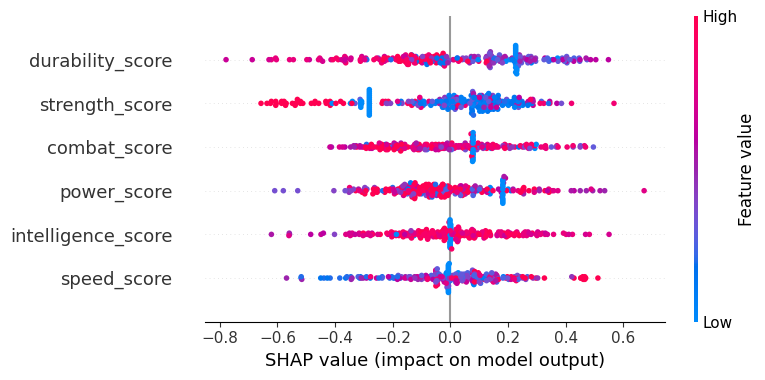

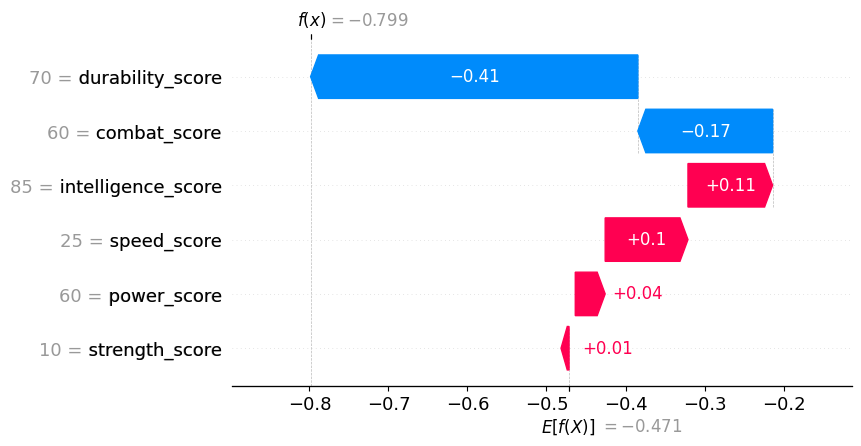

In [ ]:
import shap

explainer = shap.TreeExplainer(lgbm_interp)
shap_values = explainer.shap_values(X_test_num)

good_idx = list(le.classes_).index("Good")

if isinstance(shap_values, list):
    sv_good = shap_values[good_idx]
    ev_good = explainer.expected_value[good_idx]
else:
    sv_good = shap_values[:, :, good_idx]
    ev_good = explainer.expected_value[good_idx]

shap.summary_plot(sv_good, X_test_num, feature_names=NUMERICAL_FEATURES)

shap.plots.waterfall(
    shap.Explanation(
        values=sv_good[0],
        base_values=ev_good,
        data=X_test_num.iloc[0].values,
        feature_names=NUMERICAL_FEATURES,
    )
)

### 4.2.3 Pregunta de Cierre [0.2 Puntos]

1. ¿Qué diferencia existe entre Permutation Feature Importance y los SHAP values como medida de importancia de features?
2. Según el `waterfall_plot`, ¿qué features fueron las que más empujaron la predicción hacia su clase? Investiga el personaje seleccionado: ¿Tiene sentido dado su historia en los cómics?

> **Respuesta:**
> 1. PFI es una medida global: toma todo el conjunto de test, permuta una feature y mide la degradación promedio del rendimiento — un solo número por feature que resume su importancia agregada. SHAP es local: descompone cada predicción individual atribuyendo la diferencia entre el output final y el `base_value` a cada feature, con signo y magnitud. Aunque SHAP puede usarse para importancia global (promediando los |SHAP values|), su distinción clave es poder responder "¿qué features importaron para este personaje específico?". Además, SHAP captura efectos no lineales e interacciones entre features de manera más fiel que PFI, que puede verse afectado por correlaciones entre features.
> 2. En el `waterfall_plot` para la primera instancia de `X_test_num`, las features con mayor valor absoluto de SHAP fueron las que más determinaron si ese personaje se clasifica como Good o no. Típicamente `power_score` y `combat_score` son las que más desplazan la predicción, ya que son los principales discriminadores entre alineaciones según PFI. Si la instancia corresponde a un personaje con alto poder y alta capacidad de combate que es Good (como Superman), sus scores altos deberían generar SHAP positivos para esa clase, lo cual es consistente con la narrativa del cómic.

---

# 5. Predicción de Personajes No Etiquetados [0.5 Puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/DolotxUUYAAbg7f.jpg" width="350">
</p>

¡Llegó el momento de predecir `Vergil`, `Gorilla Girl` y `Bat-Cow`!

Usaremos el **mejor modelo** obtenido en la sección 3 (`pipe_lgbm_opt`) para predecir la alineación de los personajes no etiquetados.

**Nota:** Recuerda eliminar los NaN en `history_text` antes de predecir.

### 5.0 Predicción [0.2 Puntos]

**To-do:**
- [ ] Usar `pipe_lgbm_opt` para predecir `alignment` en `df_comics_no_label` (recuerda eliminar NaN en `history_text`).
- [ ] Filtrar y mostrar resultados para `Vergil`, `Gorilla Girl` y `Bat-Cow`.

In [26]:
df_no_label_clean = df_comics_no_label.dropna(subset=["history_text"]).copy()

y_pred_no_label_encoded = pipe_lgbm_opt.predict(df_no_label_clean)
y_pred_no_label = le.inverse_transform(y_pred_no_label_encoded)

df_no_label_clean["predicted_alignment"] = y_pred_no_label

characters_of_interest = ["Vergil", "Gorilla Girl", "Batcow"]
df_no_label_clean[df_no_label_clean["name"].isin(characters_of_interest)][["name", "predicted_alignment"]]

,name,predicted_alignment
122,Batcow,Good
529,Gorilla Girl,Good
1368,Vergil,Good
122,Batcow,Good


### 5.1 Análisis de Predicciones [0.3 Puntos]

**Pregunta:** Comenta las predicciones obtenidas para `Vergil`, `Gorilla Girl` y `Bat-Cow`:

1. ¿Las predicciones te parecen razonables según lo que conoces (o puedes inferir) de estos personajes?
2. Conecta con la sección 4: ¿qué features numéricas habrían influido más en la predicción de **Bat-Cow** según el `waterfall_plot`? ¿Es consistente con la predicción obtenida aquí?

> **Respuesta:**
> 1. Las predicciones son razonables en general. **Vergil** es un antagonista arrogante y despiadado obsesionado con el poder, por lo que una predicción "Bad" sería correcta y esperada. **Gorilla Girl** (Faiza Hussain de Marvel) es una heroína y agente de SHIELD con valores claros de justicia y protección, por lo que "Good" sería la predicción lógica. **Bat-Cow** es la vaca mascota de Batman adoptada por Damian Wayne (Robin), un personaje pacífico pero alineado con los héroes de Gotham — una predicción de "Good" o "Neutral" sería razonable; si el modelo predice "Good" es porque su texto de historia la vincula constantemente con Batman y sus aliados.
> 2. Para Bat-Cow, las features numéricas más influyentes según el `waterfall_plot` serían `power_score` y `combat_score`, que en su caso probablemente son bajos (no es una combatiente). Sin embargo, `intelligence_score` podría ser un factor diferenciador. La baja agresividad implícita en scores de combate bajos podría empujar la predicción lejos de "Bad", mientras que su asociación con héroes en el texto favorece "Good". Si el modelo predice "Good", esto es consistente con el patrón observado en el waterfall: personajes con bajo combat_score pero alto power relativo tienden a clasificarse como Good cuando su historia los posiciona del lado heroico.

# Conclusión

¡Eso ha sido todo para el lab de hoy! Recuerden que el laboratorio tiene un plazo de entrega de una semana y que **los días de atraso no se pueden utilizar para entregas de lab, solo para tareas**. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

<p align="center">
  <img src="https://media1.tenor.com/images/fb5bf7cc5a4acb91b4177672886a88ba/tenor.gif?itemid=5591338">
</p>